<a href="https://colab.research.google.com/github/Pranavi25-08/MLOps-AI-skill-Gap-Prediction-System/blob/main/AI_skill_Gap_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Synthetic_CSE_Employability_Dataset_V2_1200.xlsx to Synthetic_CSE_Employability_Dataset_V2_1200.xlsx


In [3]:
df = pd.read_excel("Synthetic_CSE_Employability_Dataset_V2_1200.xlsx")

In [4]:
df.head()

,Student_ID,Persona,Age,Gender,CGPA,Attendance,Python,Java,C++,SQL,...,DSA_Score,Aptitude,Communication,ProblemSolving,Resume_ATS,Resume_Match,Skill_Match,Missing_Skills,Industry_Demand,Employable
0,1,Excellent,20,Female,8.80,92.9,1,1,1,1,...,87,84,79,85,100,100,99,3,99,1
1,2,Excellent,20,Female,9.11,97.6,1,1,1,1,...,93,85,85,95,100,89,88,5,94,1
2,3,Excellent,22,Male,8.93,89.1,1,1,1,1,...,89,97,89,97,98,74,62,6,68,1
3,4,Excellent,22,Female,9.52,99.5,1,1,1,1,...,90,93,77,89,100,99,89,3,82,1
4,5,Excellent,23,Female,8.88,95.9,1,1,1,1,...,90,96,85,89,100,85,80,6,83,1


In [5]:
df.shape

(1200, 36)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Student_ID       1200 non-null   int64  
 1   Persona          1200 non-null   object 
 2   Age              1200 non-null   int64  
 3   Gender           1200 non-null   object 
 4   CGPA             1200 non-null   float64
 5   Attendance       1200 non-null   float64
 6   Python           1200 non-null   int64  
 7   Java             1200 non-null   int64  
 8   C++              1200 non-null   int64  
 9   SQL              1200 non-null   int64  
 10  JavaScript       1200 non-null   int64  
 11  HTML_CSS         1200 non-null   int64  
 12  React            1200 non-null   int64  
 13  NodeJS           1200 non-null   int64  
 14  Git              1200 non-null   int64  
 15  Docker           1200 non-null   int64  
 16  AWS              1200 non-null   int64  
 17  Linux         

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df["Persona"] = encoder.fit_transform(df["Persona"])

In [8]:
X = df.drop("Employable", axis=1)

y = df["Employable"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [11]:
y_pred = rf.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.8791666666666667


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86       102
           1       0.89      0.90      0.90       138

    accuracy                           0.88       240
   macro avg       0.88      0.88      0.88       240
weighted avg       0.88      0.88      0.88       240



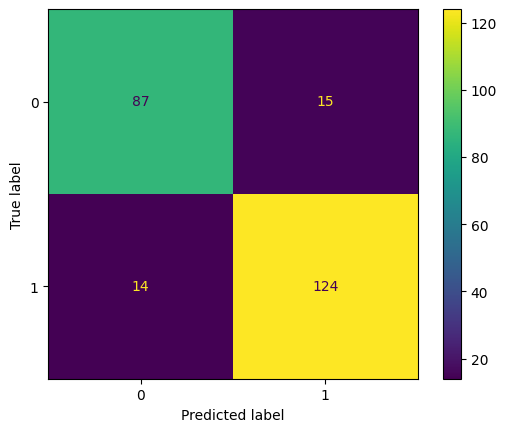

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [15]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
32,Skill_Match,0.168924
31,Resume_Match,0.112421
34,Industry_Demand,0.108657
33,Missing_Skills,0.102054
21,Projects,0.074944
26,DSA_Score,0.059459
25,OpenSource_PRs,0.044693
29,ProblemSolving,0.039296
22,Internship,0.034761
0,Student_ID,0.027440


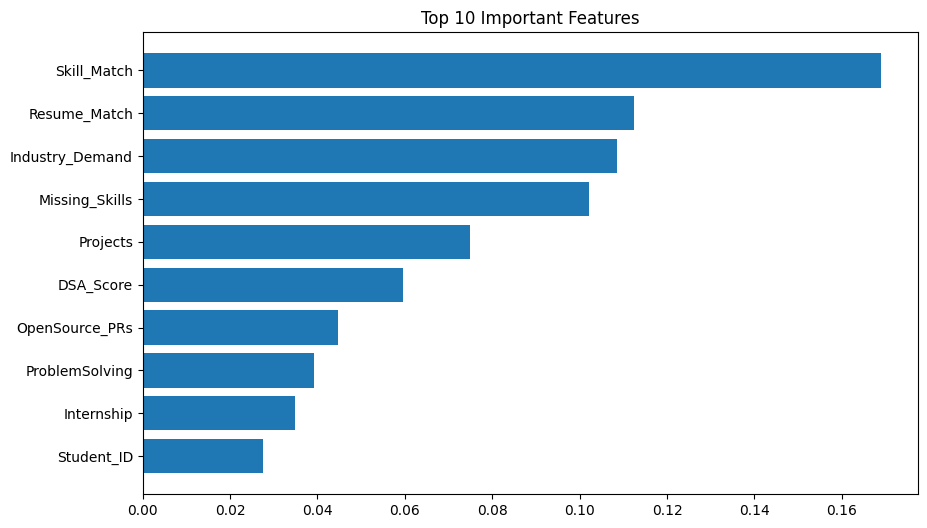

In [16]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()

In [17]:
new_student = pd.DataFrame({
    "Student_ID":[1201],
    "Persona":[1],
    "Age":[21],
    "Gender":[1],
    "CGPA":[8.3],
    "Attendance":[90],
    "Python":[1],
    "Java":[1],
    "C++":[1],
    "SQL":[1],
    "JavaScript":[1],
    "HTML_CSS":[1],
    "React":[1],
    "NodeJS":[1],
    "Git":[1],
    "Docker":[1],
    "AWS":[1],
    "Linux":[1],
    "MachineLearning":[1],
    "DeepLearning":[0],
    "DataAnalysis":[1],
    "Projects":[5],
    "Internship":[1],
    "Certifications":[4],
    "Hackathons":[2],
    "OpenSource_PRs":[10],
    "DSA_Score":[88],
    "Aptitude":[82],
    "Communication":[85],
    "ProblemSolving":[90],
    "Resume_ATS":[91],
    "Resume_Match":[89],
    "Skill_Match":[92],
    "Missing_Skills":[2],
    "Industry_Demand":[90]
})

prediction = rf.predict(new_student)

print(prediction)

[1]


In [18]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")


['random_forest_model.pkl']